## Intro
- Just playing around with visualizations for various algorithms in machine learning. 
- Will be building this out with due time.
- Here I am just creating an easy dataset to visualize then calculating a trendline in three different ways to gain an intuitive understanding of the differences.

## Method for Calculating a Line From Two Points

Given a series of points, $ (x_n, y_n)$, the most jank-ass method of calculating a trendline is just by fitting a line to the first and the last points $ (x_1, y_1)$ and $(x_n, y_n), $. This is what is done in the code block below.

### 1. Slope

$$
w = \frac{y_n - y_n}{x_2 - x_1}
$$

### 2. Intercept

Using point $(x_1, y_1)$:

$$
b = y_1 - w x_1
$$

### 3. Final Line Equation

$$
y = wx + b
$$


Jank Ass Model Cost: J_wb = 4.060870370370374


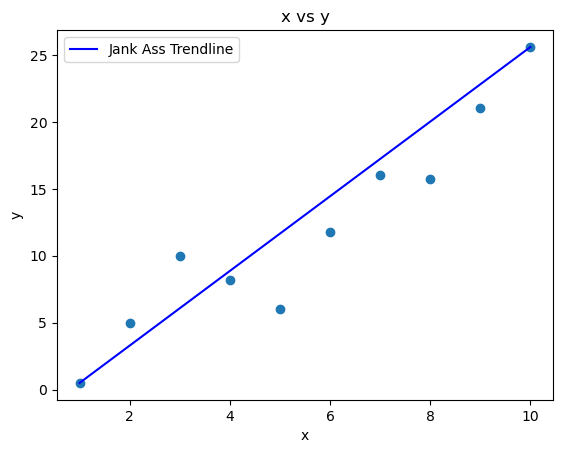

In [14]:
import matplotlib.pyplot as plt

x = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
y = [0.5, 5, 10, 8.2, 6, 11.8, 16, 15.7, 21, 25.6]
m = len(x) #length of the arrays

#this is an intentionally overly-simplified model just drawing a line between the first and the last points.
def compute_jank_ass_model(x,y):
    w = ((y[-1]-y[0])/(x[-1]-x[0]))
    b = y[0]-w*x[0]
    return w, b

def compute_cost(x, y, w, b, m):
    cost = []
    for i in range(m):
        f_wb = w * x[i] + b
        cost.append((f_wb - y[i])**2)
        #print(f'({x[i]},{y[i]}) cost: {(f_wb - y[i])**2}')
    J_wb = (1/(2*m))*sum(cost)
    return J_wb

#compute w and b for the jank ass model
w, b = compute_jank_ass_model(x,y)
J_wb = compute_cost(x,y,w,b,m)
print(f'Jank Ass Model Cost: J_wb = {J_wb}')

plt.plot([x[0], x[-1]], [y[0], y[-1]], color='blue', label = 'Jank Ass Trendline')
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.legend()
plt.show()

## Closed-Form Linear Regression (1D)

Given data points $((x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n))$, there actually exists a closed for solution. This is caulcated here in the code block below. This actually gives the theoretical correct answer but becomes impractical due to the computational expense when the datasets become too large.

### 1. Compute the mean values of each of the variables

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i
$$

$$
\bar{y} = \frac{1}{n}\sum_{i=1}^n y_i
$$

### 2. Closed form method for computing the slope fitting to n>2 points.

$$
m = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}
$$

### 3. Compute the intercept

$$
b = \bar{y} - w\bar{x}
$$

### 4. Regression line

$$
y = wx + b
$$


Mathematical Model Cost: J_wb = 2.856775757575758


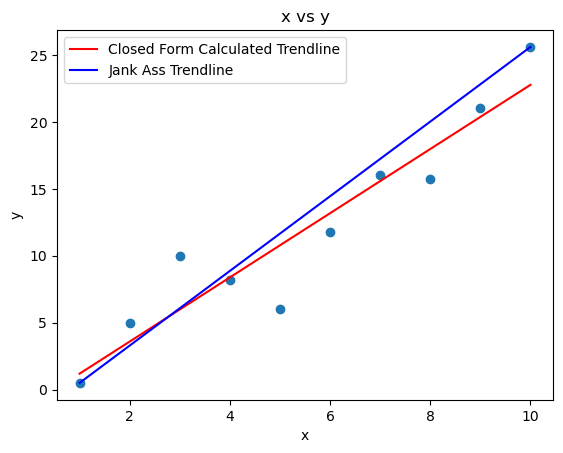

In [16]:
#this is the closed form solution for simple linear regression (1D)
def compute_mathematical_model(x,y):
    x_mean = sum(x) / m
    y_mean = sum(y) / m
    num = 0
    denom = 0
    for i in range(m):
        num += (x[i] - x_mean) * (y[i] - y_mean)
        denom += (x[i] - x_mean)**2
    w = num / denom
    b = y_mean - w * x_mean
    return w, b

def compute_cost(x, y, w, b, m):
    cost = []
    for i in range(m):
        f_wb = w * x[i] + b
        cost.append((f_wb - y[i])**2)
        #print(f'({x[i]},{y[i]}) cost: {(f_wb - y[i])**2}')
    J_wb = (1/(2*m))*sum(cost)
    return J_wb

#compute w and b for the closed form mathematical model
w, b = compute_mathematical_model(x,y)
J_wb = compute_cost(x,y,w,b,m)
y_pred_math = [w * xi + b for xi in x]
print(f'Mathematical Model Cost: J_wb = {J_wb}')

plt.plot(x, y_pred_math, color='red', label = 'Closed Form Calculated Trendline')
plt.plot([x[0], x[-1]], [y[0], y[-1]], color='blue', label = 'Jank Ass Trendline')
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.legend()
plt.show()

## Gradient Descent for Linear Regression

We want to learn parameters \(w\) and \(b\) in the model:

$$
\hat{y} = wx + b
$$

### 1. Cost Function

We minimize the mean squared error (MSE):

$$
J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} \left( wx_i + b - y_i \right)^2
$$


### 2. Compute the Gradients

**Gradient with respect to \(w\):**

$$
\frac{\partial J}{\partial w}
= \frac{1}{n} \sum_{i=1}^{n} (wx_i + b - y_i)\, x_i
$$


**Gradient with respect to \(b\):**

$$
\frac{\partial J}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n} (wx_i + b - y_i)
$$


### 3. Update Rules (Gradient Descent Step)

With learning rate $(\alpha)$:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$


### 4. Repeat Until Convergence

Loop until \(w\) and \(b\) stop changing significantly:

- compute predictions  
- compute gradients  
- update \(w\) and \(b\)  
- recompute cost \(J\)  

This iteratively moves the parameters downhill on the cost surface.


### 5. Final Model

Once converged:

$$
\hat{y} = wx + b
$$


Gradient Decent Model Cost: J_wb = 2.8587749614959925


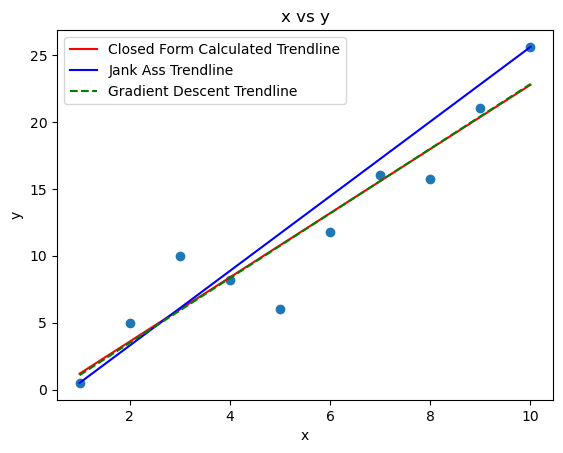

In [17]:
#this is linear regresssion computed with gradient decent
#start with the poopy w,b approximation with the jank_ass_model
def compute_grad_decent_model(x, y, w, b, m):
    iterations = 10000
    a = 0.001
    for k in range(iterations):
        error1 = []
        error2 = []
        for i in range(m):
            error1.append((w*x[i] + b - y[i]) * x[i])
            error2.append(w*x[i] + b - y[i])
        dJdw = (1/(m)) * sum(error1)
        dJdb = (1/(m)) * sum(error2)
        w = w - a * dJdw
        b = b - a * dJdb
    return w,b

def compute_cost(x, y, w, b, m):
    cost = []
    for i in range(m):
        f_wb = w * x[i] + b
        cost.append((f_wb - y[i])**2)
        #print(f'({x[i]},{y[i]}) cost: {(f_wb - y[i])**2}')
    J_wb = (1/(2*m))*sum(cost)
    return J_wb

#compute w and b using gradiaent assent starting with the jank ass model
w_init, b_init = compute_jank_ass_model(x, y)
w, b = compute_grad_decent_model(x, y, w_init, b_init, m)
J_wb = compute_cost(x,y,w,b,m)
y_pred_grad = [w * xi + b for xi in x]
print(f'Gradient Decent Model Cost: J_wb = {J_wb}')

plt.plot(x, y_pred_math, color='red', label = 'Closed Form Calculated Trendline')
plt.plot([x[0], x[-1]], [y[0], y[-1]], color='blue', label = 'Jank Ass Trendline')
plt.plot(x, y_pred_grad, color='green', ls = 'dashed', label = 'Gradient Descent Trendline')
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")
plt.legend()
plt.show()